the same as modeling_15 notebook but using df_processed_2.pkl made by Ari on Nov 8

## 1. Import Libraries and Load Data

Import all required libraries and load the processed dataset from a pickle file.

In [9]:
import pandas as pd
import numpy as np
import pickle
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.dates as mdates
import optuna
import random
import os
from tqdm import tqdm
import io
import joblib
import seaborn as sns
import json


# Load baseline_df
baseline_df = joblib.load('../../data/baseline.pkl')
baseline_df = baseline_df['baseline_df']
baseline_df.rename(columns={'predicted_sales': 'baseline_sales'}, inplace=True)

baseline_df['date'] = pd.to_datetime(baseline_df['date'])
baseline_df = baseline_df.sort_values(['store_nbr', 'item_nbr', 'date'])

# Load df for modeling
with open('../../data/df_processed_2.pkl', 'rb') as f: 
    df_scoped_processed = pickle.load(f)
df = df_scoped_processed['df_processed']

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['store_nbr', 'item_nbr', 'date'])

# Ensure consistent data types for merging
df['store_nbr'] = df['store_nbr'].astype('uint8')
baseline_df['store_nbr'] = baseline_df['store_nbr'].astype('uint8')

df['item_nbr'] = df['item_nbr'].astype(str)
baseline_df['item_nbr'] = baseline_df['item_nbr'].astype(str)

df['date'] = pd.to_datetime(df['date'])
baseline_df['date'] = pd.to_datetime(baseline_df['date'])

# Merge baseline_df and df for modeling
df = df.merge(baseline_df[['store_nbr', 'item_nbr', 'date', 'baseline_sales']],
              on=['store_nbr', 'item_nbr', 'date'],
              how='left')

# Load baseline trainingsdata
with open('../../data/baseline_trainingsdata.pkl', 'rb') as f: 
    df_baseline_trainingsdata = pickle.load(f)
df_baseline_trainingsdata = df_baseline_trainingsdata['baseline_df']

df_baseline_trainingsdata.rename(columns={'predicted_sales': 'baseline_sales'}, inplace=True)

df_baseline_trainingsdata['date'] = pd.to_datetime(df_baseline_trainingsdata['date'])
df_baseline_trainingsdata = df_baseline_trainingsdata.sort_values(['store_nbr', 'item_nbr', 'date'])


print(f"the min date in df is {df['date'].min()}")
print(f"the max date in df is {df['date'].max()}")
print(f'df_baseline_trainingsdata columns are:{df_baseline_trainingsdata.columns}')
print(f'df columns before merge with baseline trainingsdata:{df.columns}')

# Merge df_baseline_trainingsdata and df for modeling
df =df.merge(df_baseline_trainingsdata[['store_nbr', 'item_nbr', 'date', 'baseline_sales']],
              on=['store_nbr', 'item_nbr', 'date'],
              how='left')

print(f'df columns after merge with baseline trainingsdata:{df.columns}')

# -----------------------------
# Fix randomness for reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# -----------------------------
# Add path to 'package' folder
# -----------------------------

import sys
import os

# Get the parent folder of the notebook
notebook_dir = os.getcwd()               # should be .../3_modeling
parent_dir = os.path.dirname(notebook_dir)  # go up one level

# Add the sibling folder 'package' to sys.path
sys.path.append(os.path.join(parent_dir, 'package'))

# Now you can import the module
from m_baseline_model import f_baseline_model
from m_metrics import f_asym_wmae, f_compute_metrics
from m_train_test_cutoff_month import f_split_time_series_month
from m_metrics_monthly import f_metrics_monthly




the min date in df is 2014-01-02 00:00:00
the max date in df is 2017-08-15 00:00:00
df_baseline_trainingsdata columns are:Index(['date', 'store_nbr', 'item_nbr', 'baseline_sales', 'onpromotion',
       'month', 'family', 'city', 'state', 'type_store', 'type_holiday',
       'locale', 'locale_name', 'description', 'transferred', 'id',
       'unit_sales', 'day', 'class', 'perishable', 'cluster', 'oil_price',
       'temperature_2m_max', 'salary_payment', 'magnitude', 'weight',
       'weekday', 'quarter'],
      dtype='object')
df columns before merge with baseline trainingsdata:Index(['store_nbr', 'item_nbr', 'month', 'family', 'city', 'state',
       'type_store', 'type_holiday', 'locale', 'locale_name', 'description',
       'transferred', 'unit_sales', 'id', 'onpromotion', 'day', 'class',
       'perishable', 'cluster', 'type_priority', 'temperature_2m_max',
       'salary_payment', 'magnitude', 'date', 'oil_price', 'baseline_sales'],
      dtype='object')
df columns after merge wit

### 1.1 Merge baseline_sales_x and baseline_sales_y

In [10]:
# For baseline_sales_x
min_date_x = df.loc[df['baseline_sales_x'].notna(), 'date'].min()
max_date_x = df.loc[df['baseline_sales_x'].notna(), 'date'].max()

# For baseline_sales_y
min_date_y = df.loc[df['baseline_sales_y'].notna(), 'date'].min()
max_date_y = df.loc[df['baseline_sales_y'].notna(), 'date'].max()

print("baseline_sales_x:", min_date_x, "to", max_date_x)
print("baseline_sales_y:", min_date_y, "to", max_date_y)

df['baseline_sales'] = df['baseline_sales_y'].combine_first(df['baseline_sales_x'])
df = df.drop(columns=['baseline_sales_x', 'baseline_sales_y'])

### 1.1 Inspect the merged df
print(df['baseline_sales'].isna().sum())  # should be 0 if all dates covered
print(df['baseline_sales'].describe())



baseline_sales_x: 2017-03-23 00:00:00 to 2017-08-15 00:00:00
baseline_sales_y: 2014-01-30 00:00:00 to 2017-03-22 00:00:00
220957
count    1.762114e+06
mean     1.104768e+01
std      1.195411e+01
min      0.000000e+00
25%      4.250000e+00
50%      7.666667e+00
75%      1.375000e+01
max      3.715000e+02
Name: baseline_sales, dtype: float64


### 1.2 Doublecheck df

In [11]:
print(df.columns)
print(df.info())         # Overview of columns, types, non-nulls
print(df.describe())     # Summary statistics for numeric columns
print(df.head())         # First 5 rows


Index(['store_nbr', 'item_nbr', 'month', 'family', 'city', 'state',
       'type_store', 'type_holiday', 'locale', 'locale_name', 'description',
       'transferred', 'unit_sales', 'id', 'onpromotion', 'day', 'class',
       'perishable', 'cluster', 'type_priority', 'temperature_2m_max',
       'salary_payment', 'magnitude', 'date', 'oil_price', 'baseline_sales'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1983071 entries, 0 to 1983070
Data columns (total 26 columns):
 #   Column              Dtype         
---  ------              -----         
 0   store_nbr           uint8         
 1   item_nbr            object        
 2   month               category      
 3   family              category      
 4   city                category      
 5   state               category      
 6   type_store          category      
 7   type_holiday        category      
 8   locale              category      
 9   locale_name         category      
 10  description  

## 2.1 Monthly-item Aggregation and Feature Engineering

In [12]:
# 1️⃣ Add ISO week/year and holiday features
df['iso_year'] = df['date'].dt.isocalendar().year
df['iso_week'] = df['date'].dt.isocalendar().week
df['year_month'] = df['date'].dt.to_period('M')

df['is_holiday'] = df['type_holiday'].isin(['Holiday', 'Additional', 'Transfer', 'Bridge']).astype(int)
df['is_event'] = (df['type_holiday'] == 'Event').astype(int)
df['is_work_day'] = (df['type_holiday'] == 'Work Day').astype(int)
df['is_transferred'] = (df['transferred'] == True).astype(int)

# 2️⃣ Ensure numeric columns
for col in ['unit_sales', 'onpromotion', 'oil_price', 'temperature_2m_max', 'salary_payment', 'baseline_sales']:
    df[col] = df[col].astype(float)

# 3️⃣ Aggregate to item-month level
item_month_data = df.groupby(['item_nbr', 'year_month']).agg({
    'unit_sales': 'sum',
    'onpromotion': 'sum',
    'oil_price': 'mean',
    'temperature_2m_max': 'mean',
    'salary_payment': 'sum',
    'baseline_sales': 'sum',
    'is_holiday': 'sum',
    'is_event': 'sum',
    'is_work_day': 'sum',
    'date': 'first'
}).reset_index()

# 4️⃣ Create full grid of all item-months
all_items = df['item_nbr'].unique()
item_month_grid = pd.MultiIndex.from_product([
    all_items,
    df['year_month'].unique()
], names=['item_nbr', 'year_month']).to_frame(index=False)

# 5️⃣ Merge aggregated data with full grid
df_monthly = item_month_grid.merge(
    item_month_data,
    on=['item_nbr', 'year_month'],
    how='left'
).sort_values(['item_nbr', 'year_month'])

df_monthly['month']=df_monthly['date'].dt.month

print("Before lag merge:", len(df_monthly))

# 6️⃣ Create lag features (item-month level)
# Ensure 'date' or 'year_month' is datetime/period and the DataFrame is sorted
df_monthly['date'] = pd.to_datetime(df_monthly['date'])
df_monthly = df_monthly.sort_values(['item_nbr', 'date']).reset_index(drop=True)

# Create lag features
for h in [1, 2, 3, 4]:
    df_monthly[f'lag_{h}_month'] = df_monthly.groupby('item_nbr')['unit_sales'].shift(h)


# 7️⃣ Create 1–3 month ahead targets
for months_ahead in [1, 2, 3]:
    target = df_monthly[['item_nbr', 'year_month', 'unit_sales']].copy()
    target['year_month'] = target['year_month'] - months_ahead
    target = target.rename(columns={'unit_sales': f'{months_ahead}_month_target'})
    
    df_monthly = df_monthly.merge(target, on=['item_nbr', 'year_month'], how='left')

# 8️⃣ Baseline-derived features
df_monthly['baseline_ratio'] = df_monthly['unit_sales'] / df_monthly['baseline_sales'].clip(lower=1)
df_monthly['baseline_ma'] = (
    df_monthly.groupby('item_nbr')['baseline_sales']
    .transform(lambda x: x.rolling(4, min_periods=1).mean()))

df_monthly['baseline_std'] = (
    df_monthly.groupby('item_nbr')['baseline_sales']
    .transform(lambda x: x.rolling(4, min_periods=1).std()))

# 9️⃣ Validation
print("Final row count:", len(df_monthly))
print("Duplicate item-month keys:", df_monthly.duplicated(subset=['item_nbr', 'year_month']).sum())

print("Data completeness check:")
print(f"Items: {len(all_items)}")
print(f"Total rows expected: {len(item_month_grid)}")
print(f"Actual rows in df_monthly: {len(df_monthly)}")
print("\nMissing values in features:")
print(df_monthly.isna().sum())

print(f"\nThe number of duplicate item-month combos is: {df_monthly.duplicated(subset=['item_nbr', 'year_month']).sum()}")

print(df_monthly[df_monthly['unit_sales']==0])
zero_sales_count = (df_monthly['unit_sales'] == 0).sum()
print(f"Number of zero-sales rows: {zero_sales_count}")
print(f"Number of missing sales rows: {len(df_monthly[df_monthly['unit_sales'].isna()])}")
print(f"the lastt missing sales rows are: \n {df_monthly[df_monthly['unit_sales'].isna()].tail(5)}")

Before lag merge: 8360
Final row count: 8360
Duplicate item-month keys: 0
Data completeness check:
Items: 190
Total rows expected: 8360
Actual rows in df_monthly: 8360

Missing values in features:
item_nbr                0
year_month              0
unit_sales              0
onpromotion             0
oil_price               0
temperature_2m_max      0
salary_payment          0
baseline_sales          0
is_holiday              0
is_event                0
is_work_day             0
date                    0
month                   0
lag_1_month           190
lag_2_month           380
lag_3_month           570
lag_4_month           760
1_month_target        190
2_month_target        380
3_month_target        570
baseline_ratio          0
baseline_ma             0
baseline_std          190
dtype: int64

The number of duplicate item-month combos is: 0
       item_nbr year_month  unit_sales  onpromotion   oil_price  \
126   1018878.0    2017-03         0.0          0.0   49.274516   
127   101

## Define FEATURES and TARGET

In [13]:
# Use correct feature names
FEATURES = ['lag_1_month', 'lag_2_month', 'lag_3_month', 'lag_4_month',
    'baseline_sales', 'baseline_ma', 'baseline_ratio', 'baseline_std',
    'salary_payment', 'onpromotion',
    'is_event', 'is_holiday', 'is_work_day', 
    'month']

# Correct target columns
TARGET_1_MONTH = '1_month_target'
TARGET_2_MONTH = '2_month_target'
TARGET_3_MONTH = '3_month_target'


## 3. Define final validation set and training set for cross validation

In [14]:

# Use helper function from module
df_trainval, df_test_final, cutoff_date = f_split_time_series_month(df_monthly, date_col="date", test_months=7, buffer_months=4)
print(f"the column names in df_weekly are {df_monthly.columns}")
print(f"the column names in df_trainval are {df_trainval.columns}")
print(f'the df_test_final runs from {df_test_final["date"].min()} to {df_test_final["date"].max()}')
print(f'the df_trainval runs from {df_trainval["date"].min()} to {df_trainval["date"].max()}')




print(f"the number of unique months in df_test_final is {df_test_final['year_month'].nunique()}")

start = df_test_final['year_month'].min()
end = df_test_final['year_month'].max()
expected_months = (end - start).n + 1

print(f"the number of expected unique months in df_test_final is {expected_months}")

print(f"the number of unique (item_nbr, year_month) combinations in df_test_final is {df_test_final[['item_nbr', 'year_month']].drop_duplicates().shape[0]}")
print(f"the number of expected (item_nbr, year_month) combinations in df_test_final is {len(df_test_final['item_nbr'].unique()) * (expected_months)}")



the column names in df_weekly are Index(['item_nbr', 'year_month', 'unit_sales', 'onpromotion', 'oil_price',
       'temperature_2m_max', 'salary_payment', 'baseline_sales', 'is_holiday',
       'is_event', 'is_work_day', 'date', 'month', 'lag_1_month',
       'lag_2_month', 'lag_3_month', 'lag_4_month', '1_month_target',
       '2_month_target', '3_month_target', 'baseline_ratio', 'baseline_ma',
       'baseline_std'],
      dtype='object')
the column names in df_trainval are Index(['item_nbr', 'year_month', 'unit_sales', 'onpromotion', 'oil_price',
       'temperature_2m_max', 'salary_payment', 'baseline_sales', 'is_holiday',
       'is_event', 'is_work_day', 'month', 'lag_1_month', 'lag_2_month',
       'lag_3_month', 'lag_4_month', '1_month_target', '2_month_target',
       '3_month_target', 'baseline_ratio', 'baseline_ma', 'baseline_std',
       'date'],
      dtype='object')
the df_test_final runs from 2017-01-01 00:00:00 to 2017-08-01 00:00:00
the df_trainval runs from 2014-01-0

## 4. Hyperparameter Optimization with Cross-Validation for 1 month ahead prediction

In [15]:
RUN_OPTUNA = False
params_file = "best_params_1_month.json"

# Ensure 'date' is a column
if 'date' in df_trainval.index.names:
    df_trainval = df_trainval.reset_index(level='date', drop=True)

df_trainval['date'] = pd.to_datetime(df_trainval['date'])
df_trainval = df_trainval.sort_values('date').reset_index(drop=True)

# Remove negative or NaN sales
df_trainval = df_trainval.dropna(subset=[TARGET_1_MONTH])
df_trainval[TARGET_1_MONTH] = df_trainval[TARGET_1_MONTH].clip(lower=0)

# Ensure df_trainval is sorted by date for TimeSeriesSplit
df_trainval = df_trainval.sort_values('date').reset_index(drop=True)
dates = df_trainval['date'].values
tss = TimeSeriesSplit(n_splits=5, test_size=50, gap=7)

if RUN_OPTUNA:
    print("Running Optuna tuning for 1-month ahead target...")

    # --- Optuna objective function ---
    def objective_xgb(trial):
        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "seed": SEED,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "lambda": trial.suggest_float("lambda", 1e-3, 10.0, log=True),
            "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
            "verbosity": 0
        }
        scores = []
        for train_idx, val_idx in tss.split(dates):
            train_dates, val_dates = dates[train_idx], dates[val_idx]
            train = df_trainval[df_trainval['date'].isin(train_dates)]
            val = df_trainval[df_trainval['date'].isin(val_dates)]
            X_train, y_train = train[FEATURES], np.log1p(train[TARGET_1_MONTH])
            X_val, y_val = val[FEATURES], np.log1p(val[TARGET_1_MONTH])
            dtrain = xgb.DMatrix(X_train, label=y_train)
            dval = xgb.DMatrix(X_val, label=y_val)
            model = xgb.train(params, dtrain, num_boost_round=5000,
                              evals=[(dval, "val")], early_stopping_rounds=50, verbose_eval=False)
            val_pred = model.predict(dval, iteration_range=(0, model.best_iteration))
            scores.append(np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_pred))))
        return np.mean(scores)

    study_xgb = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
    study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)
    best_params_xgb_1_month = study_xgb.best_params

    # --- Re-run CV to get average best iteration ---
    best_iters_xgb = []
    for train_idx, val_idx in tss.split(dates):
        train_dates, val_dates = dates[train_idx], dates[val_idx]
        train = df_trainval[df_trainval['date'].isin(train_dates)]
        val = df_trainval[df_trainval['date'].isin(val_dates)]
        X_train, y_train = train[FEATURES], np.log1p(train[TARGET_1_MONTH])
        X_val, y_val = val[FEATURES], np.log1p(val[TARGET_1_MONTH])
        dtrain = xgb.DMatrix(X_train, label=y_train)
        dval = xgb.DMatrix(X_val, label=y_val)
        model = xgb.train(best_params_xgb_1_month, dtrain, num_boost_round=5000,
                          evals=[(dval, "val")], early_stopping_rounds=50, verbose_eval=False)
        best_iters_xgb.append(model.best_iteration)

    avg_best_iter_xgb_1_month = int(np.mean(best_iters_xgb))
    print("Average best iteration 1 month XGB:", avg_best_iter_xgb_1_month)

    # Save params
    with open(params_file, "w") as f:
        json.dump({
            "xgb_1_month": best_params_xgb_1_month,
            "avg_best_iter_xgb_1_month": avg_best_iter_xgb_1_month
        }, f)

else:
    print("Loading existing best parameters from JSON...")
    with open(params_file, "r") as f:
        best_params = json.load(f)
    best_params_xgb_1_month = best_params["xgb_1_month"]
    avg_best_iter_xgb_1_month = best_params.get("avg_best_iter_xgb_1_month", 1000)

print("XGB params:", best_params_xgb_1_month)
print("Average best iteration:", avg_best_iter_xgb_1_month)


Loading existing best parameters from JSON...
XGB params: {'learning_rate': 0.024397573839134667, 'max_depth': 10, 'subsample': 0.9935957812753095, 'colsample_bytree': 0.74469825516469, 'lambda': 0.6851269338819642, 'alpha': 0.041165467187075325}
Average best iteration: 2951


## Optuna for 2 months ahead predictions

In [16]:

RUN_OPTUNA = False
params_file = "best_params_2_month.json"

# Ensure 'date' is a column
if 'date' in df_trainval.index.names:
    df_trainval = df_trainval.reset_index(level='date', drop=True)

df_trainval['date'] = pd.to_datetime(df_trainval['date'])
df_trainval = df_trainval.sort_values('date').reset_index(drop=True)

# Remove negative or NaN sales
df_trainval = df_trainval.dropna(subset=[TARGET_2_MONTH])
df_trainval[TARGET_2_MONTH] = df_trainval[TARGET_2_MONTH].clip(lower=0)

# Ensure df_trainval is sorted by date for TimeSeriesSplit
df_trainval = df_trainval.sort_values('date').reset_index(drop=True)
dates = df_trainval['date'].values
tss = TimeSeriesSplit(n_splits=5, test_size=50, gap=7)

if RUN_OPTUNA:
    print("Running Optuna tuning for 2-month ahead target...")

    # --- Optuna objective function ---
    def objective_xgb(trial):
        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "seed": SEED,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "lambda": trial.suggest_float("lambda", 1e-3, 10.0, log=True),
            "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
            "verbosity": 0
        }
        scores = []
        for train_idx, val_idx in tss.split(dates):
            train_dates, val_dates = dates[train_idx], dates[val_idx]
            train = df_trainval[df_trainval['date'].isin(train_dates)]
            val = df_trainval[df_trainval['date'].isin(val_dates)]
            X_train, y_train = train[FEATURES], np.log1p(train[TARGET_2_MONTH])
            X_val, y_val = val[FEATURES], np.log1p(val[TARGET_2_MONTH])
            dtrain = xgb.DMatrix(X_train, label=y_train)
            dval = xgb.DMatrix(X_val, label=y_val)
            model = xgb.train(params, dtrain, num_boost_round=5000,
                              evals=[(dval, "val")], early_stopping_rounds=50, verbose_eval=False)
            val_pred = model.predict(dval, iteration_range=(0, model.best_iteration))
            scores.append(np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_pred))))
        return np.mean(scores)

    study_xgb = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
    study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)
    best_params_xgb_2_month = study_xgb.best_params

    # --- Re-run CV to get average best iteration ---
    best_iters_xgb = []
    for train_idx, val_idx in tss.split(dates):
        train_dates, val_dates = dates[train_idx], dates[val_idx]
        train = df_trainval[df_trainval['date'].isin(train_dates)]
        val = df_trainval[df_trainval['date'].isin(val_dates)]
        X_train, y_train = train[FEATURES], np.log1p(train[TARGET_2_MONTH])
        X_val, y_val = val[FEATURES], np.log1p(val[TARGET_2_MONTH])
        dtrain = xgb.DMatrix(X_train, label=y_train)
        dval = xgb.DMatrix(X_val, label=y_val)
        model = xgb.train(best_params_xgb_2_month, dtrain, num_boost_round=5000,
                          evals=[(dval, "val")], early_stopping_rounds=50, verbose_eval=False)
        best_iters_xgb.append(model.best_iteration)

    avg_best_iter_xgb_2_month = int(np.mean(best_iters_xgb))
    print("Average best iteration 2 months XGB:", avg_best_iter_xgb_2_month)

    # Save params
    with open(params_file, "w") as f:
        json.dump({
            "xgb_2_month": best_params_xgb_2_month,
            "avg_best_iter_xgb_2_month": avg_best_iter_xgb_2_month
        }, f)

else:
    print("Loading existing best parameters from JSON...")
    with open(params_file, "r") as f:
        best_params = json.load(f)
    best_params_xgb_2_month = best_params["xgb_2_month"]
    avg_best_iter_xgb_2_month = best_params.get("avg_best_iter_xgb_2_month", 1000)

print("XGB params:", best_params_xgb_2_month)
print("Average best iteration:", avg_best_iter_xgb_2_month)


Loading existing best parameters from JSON...
XGB params: {'learning_rate': 0.031938975479410735, 'max_depth': 9, 'subsample': 0.6837572979557527, 'colsample_bytree': 0.8897170959411489, 'lambda': 2.529726092208916, 'alpha': 0.015768960015755312}
Average best iteration: 2822


## Optuna code for 3 months ahead prediction

In [17]:
import os
import json

# -----------------------------
# Set this to True if you *want* to force re-run of Optuna
RUN_OPTUNA = False
params_file = "best_params_3_month.json"

# Ensure 'date' is a column
if 'date' in df_trainval.index.names:
    df_trainval = df_trainval.reset_index(level='date', drop=True)

# Ensure datetime type
df_trainval['date'] = pd.to_datetime(df_trainval['date'])

# Sort chronologically
df_trainval = df_trainval.sort_values('date').reset_index(drop=True)

# Remove negative or NaN sales
df_trainval = df_trainval.dropna(subset=[TARGET_3_MONTH])
df_trainval[TARGET_3_MONTH] = df_trainval[TARGET_3_MONTH].clip(lower=0)

# Ensure df_trainval is sorted by date for TimeSeriesSplit
df_trainval = df_trainval.sort_values('date').reset_index(drop=True)
dates = df_trainval['date'].values
tss = TimeSeriesSplit(n_splits=5, test_size=50, gap=7)

# -----------------------------
# Run Optuna tuning or load existing params
# -----------------------------
if RUN_OPTUNA or not os.path.exists(params_file):
    print("Running Optuna tuning for 3-month ahead target...")

    # --- Optuna objective function ---
    def objective_xgb(trial):
        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "seed": SEED,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "lambda": trial.suggest_float("lambda", 1e-3, 10.0, log=True),
            "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
            "verbosity": 0
        }
        scores = []
        for train_idx, val_idx in tss.split(dates):
            train_dates, val_dates = dates[train_idx], dates[val_idx]
            train = df_trainval[df_trainval['date'].isin(train_dates)]
            val = df_trainval[df_trainval['date'].isin(val_dates)]
            X_train, y_train = train[FEATURES], np.log1p(train[TARGET_3_MONTH])
            X_val, y_val = val[FEATURES], np.log1p(val[TARGET_3_MONTH])
            dtrain = xgb.DMatrix(X_train, label=y_train)
            dval = xgb.DMatrix(X_val, label=y_val)
            model = xgb.train(params, dtrain, num_boost_round=5000,
                              evals=[(dval, "val")], early_stopping_rounds=50, verbose_eval=False)
            val_pred = model.predict(dval, iteration_range=(0, model.best_iteration))
            scores.append(np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_pred))))
        return np.mean(scores)

    study_xgb = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
    study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)
    best_params_xgb_3_month = study_xgb.best_params

    # --- Re-run CV to get average best iteration ---
    best_iters_xgb = []
    for train_idx, val_idx in tss.split(dates):
        train_dates, val_dates = dates[train_idx], dates[val_idx]
        train = df_trainval[df_trainval['date'].isin(train_dates)]
        val = df_trainval[df_trainval['date'].isin(val_dates)]
        X_train, y_train = train[FEATURES], np.log1p(train[TARGET_3_MONTH])
        X_val, y_val = val[FEATURES], np.log1p(val[TARGET_3_MONTH])
        dtrain = xgb.DMatrix(X_train, label=y_train)
        dval = xgb.DMatrix(X_val, label=y_val)
        model = xgb.train(best_params_xgb_3_month, dtrain, num_boost_round=5000,
                          evals=[(dval, "val")], early_stopping_rounds=50, verbose_eval=False)
        best_iters_xgb.append(model.best_iteration)

    avg_best_iter_xgb_3_month = int(np.mean(best_iters_xgb))
    print("Average best iteration 3 months XGB:", avg_best_iter_xgb_3_month)

    # Save params
    with open(params_file, "w") as f:
        json.dump({
            "xgb_3_month": best_params_xgb_3_month,
            "avg_best_iter_xgb_3_month": avg_best_iter_xgb_3_month
        }, f)

else:
    print("Loading existing best parameters from JSON...")
    with open(params_file, "r") as f:
        best_params = json.load(f)
    best_params_xgb_3_month = best_params["xgb_3_month"]
    avg_best_iter_xgb_3_month = best_params.get("avg_best_iter_xgb_3_month", 1000)

print("XGB params:", best_params_xgb_3_month)
print("Average best iteration:", avg_best_iter_xgb_3_month)


Loading existing best parameters from JSON...
XGB params: {'learning_rate': 0.04280980530829741, 'max_depth': 10, 'subsample': 0.8499172811083083, 'colsample_bytree': 0.6173125943296163, 'lambda': 0.17974443586546657, 'alpha': 0.0010997776663890775}
Average best iteration: 3162


## 6. Train on full trainval 

Training 1-month ahead model...

Training 2-months ahead model...

Training 3-months ahead model...

Models have been trained and saved successfully!


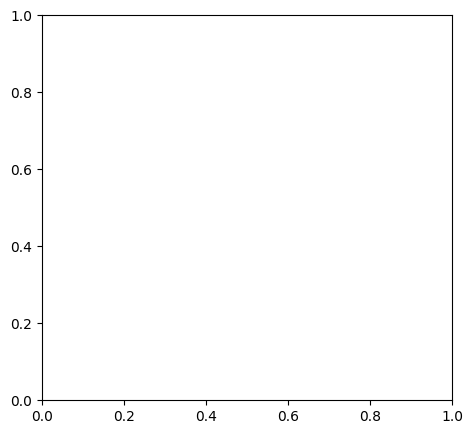

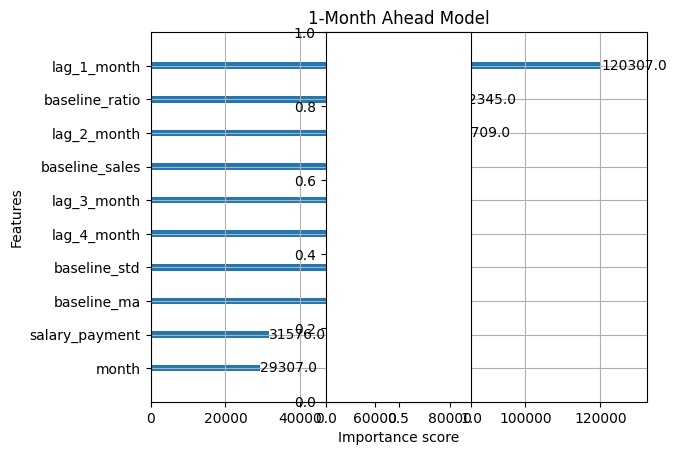

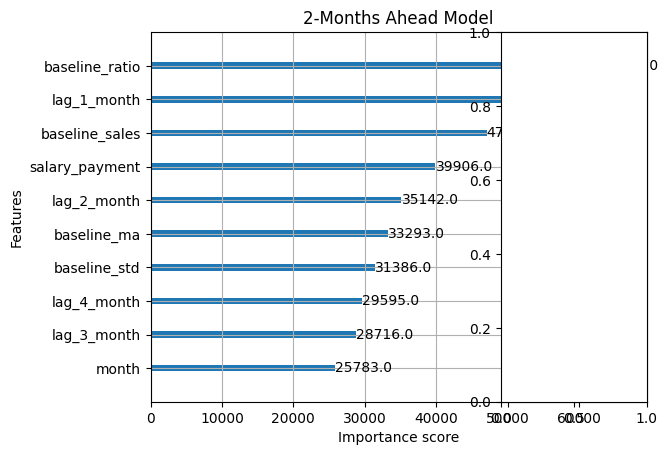

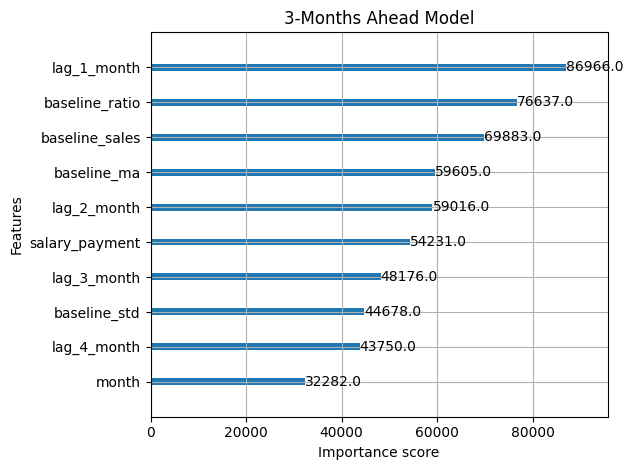

In [18]:
# Train models on full dataset for 1-month and 2-months ahead predictions
import xgboost as xgb

# Create DMatrix for training (full dataset)
train_1_month = df_trainval.dropna(subset=[TARGET_1_MONTH])
train_2_month = df_trainval.dropna(subset=[TARGET_2_MONTH])
train_3_month = df_trainval.dropna(subset=[TARGET_3_MONTH])

dtrain_1_month = xgb.DMatrix(data=train_1_month[FEATURES], label=train_1_month[TARGET_1_MONTH])
dtrain_2_month = xgb.DMatrix(data=train_2_month[FEATURES], label=train_2_month[TARGET_2_MONTH])
dtrain_3_month = xgb.DMatrix(data=train_3_month[FEATURES], label=train_3_month[TARGET_3_MONTH])

# Set XGBoost parameters
params_1_month = best_params_xgb_1_month.copy()
params_2_month = best_params_xgb_2_month.copy()
params_3_month = best_params_xgb_3_month.copy()

# Train model for 1-month ahead predictions
print("Training 1-month ahead model...")
model_1_month = xgb.train(
    params=params_1_month,
    dtrain=dtrain_1_month,
    num_boost_round=avg_best_iter_xgb_1_month,
    verbose_eval=10)

# Train model for 2-months ahead predictions
print("\nTraining 2-months ahead model...")
model_2_month = xgb.train(
    params=params_2_month,
    dtrain=dtrain_2_month,
    num_boost_round=avg_best_iter_xgb_2_month,
    verbose_eval=10)

# Train model for 3-months ahead predictions
print("\nTraining 3-months ahead model...")
model_3_month = xgb.train(
    params=params_3_month,
    dtrain=dtrain_3_month,
    num_boost_round=avg_best_iter_xgb_3_month,
    verbose_eval=10)

# Save the models
model_1_month.save_model('monthly_forecast_model_1_month.json')
model_2_month.save_model('monthly_forecast_model_2_month.json')
model_3_month.save_model('monthly_forecast_model_3_month.json')
print("\nModels have been trained and saved successfully!")

# Feature importance for both models
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
xgb.plot_importance(model_1_month, max_num_features=10, title='1-Month Ahead Model')
plt.subplot(1, 3, 2)
xgb.plot_importance(model_2_month, max_num_features=10, title='2-Months Ahead Model')
plt.subplot(1, 3, 3)
xgb.plot_importance(model_3_month, max_num_features=10, title='3-Months Ahead Model')
plt.tight_layout()
plt.show()


## validate on final test data

In [19]:
# -----------------------------
# Iterative multi-step prediction for 1–3 months ahead
# -----------------------------

# Copy test set and reset index to avoid ambiguity
df_test_iter = df_test_final.copy().reset_index(drop=True)

# Ensure 'date' is datetime
df_test_iter['date'] = pd.to_datetime(df_test_iter['date'])

# Sort by item and date
df_test_iter = df_test_iter.sort_values(['item_nbr', 'date']).reset_index(drop=True)

# Define models and prediction column names
models = [model_1_month, model_2_month, model_3_month]
pred_cols = ['pred_xgb_1_month', 'pred_xgb_2_month', 'pred_xgb_3_month']

# Iterate over each forecast horizon
for step, (model, pred_col) in enumerate(zip(models, pred_cols), start=1):
    print(f"Predicting {step}-month ahead...")

    # Process each item separately
    for item in df_test_iter['item_nbr'].unique():
        item_mask = df_test_iter['item_nbr'] == item
        item_data = df_test_iter[item_mask].copy()
        item_indices = item_data.index.to_list()  # ensures chronological order

        for pos, idx in enumerate(item_indices):
            # Prepare features as DataFrame to keep column names
            X = item_data.loc[[idx], FEATURES]  # double brackets!
            dX = xgb.DMatrix(X, enable_categorical=True)

            # Predict
            pred = model.predict(dX)[0]
            df_test_iter.loc[idx, pred_col] = pred

            # Update lag features for the next row if exists
            if pos + 1 < len(item_indices):
                next_idx = item_indices[pos + 1]
                # Shift lag features: lag_1 -> lag_2, lag_2 -> lag_3, etc.
                for h in range(4, 1, -1):  # lag_4 down to lag_2
                    df_test_iter.loc[next_idx, f'lag_{h}_month'] = df_test_iter.loc[idx, f'lag_{h-1}_month']
                # Set lag_1 as current prediction
                df_test_iter.loc[next_idx, 'lag_1_month'] = pred

    print(f"{step}-month ahead predictions done.\n")

# -----------------------------
# Sum predictions for 3-month horizon
# -----------------------------
df_test_iter['pred_sum_3_months'] = (
    df_test_iter['pred_xgb_1_month'] +
    df_test_iter['pred_xgb_2_month'] +
    df_test_iter['pred_xgb_3_month']
)

# Baseline sum (for comparison)
df_test_iter['baseline_sum_3_months'] = df_test_iter['baseline_sales'] * 3

# True 3-month sales
df_test_iter['true_sum_3_months'] = (
    df_test_iter['1_month_target'] +
    df_test_iter['2_month_target'] +
    df_test_iter['3_month_target']
)

# Evaluate metrics
metrics_combined = f_metrics_monthly(
    df_test_iter,
    y_true_col='true_sum_3_months',
    y_pred_cols=['pred_sum_3_months', 'baseline_sum_3_months']
)
print(metrics_combined)


Predicting 1-month ahead...
1-month ahead predictions done.

Predicting 2-month ahead...
2-month ahead predictions done.

Predicting 3-month ahead...
3-month ahead predictions done.

     month             prediction     rmse      mae          mape    rae  \
0  2017-05      pred_sum_3_months  2512.71  1744.51  3.058293e+10  32.81   
1  2017-05  baseline_sum_3_months  3454.79  2493.56  3.527184e+10  46.89   
2  Average  baseline_sum_3_months  3454.79  2493.56  3.527184e+10  46.89   
3  Average      pred_sum_3_months  2512.71  1744.51  3.058293e+10  32.81   

    bias  over_delivery  under_delivery  total_sales  
0 -28.64         310407           21048      1010308  
1 -44.68         462602           11174      1010308  
2 -44.68         462602           11174      1010308  
3 -28.64         310407           21048      1010308  


## 8. Plot Forecasts - BASELINE, XGB


Plot total daily, weekly, and monthly forecasts using matplotlib for visual inspection.

C:\Users\jasmi\AppData\Local\Temp\ipykernel_24988\2501345131.py:5: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if pd.api.types.is_period_dtype(df_test_iter[date_col]):
C:\Users\jasmi\AppData\Local\Temp\ipykernel_24988\2501345131.py:17: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if pd.api.types.is_period_dtype(x_vals):


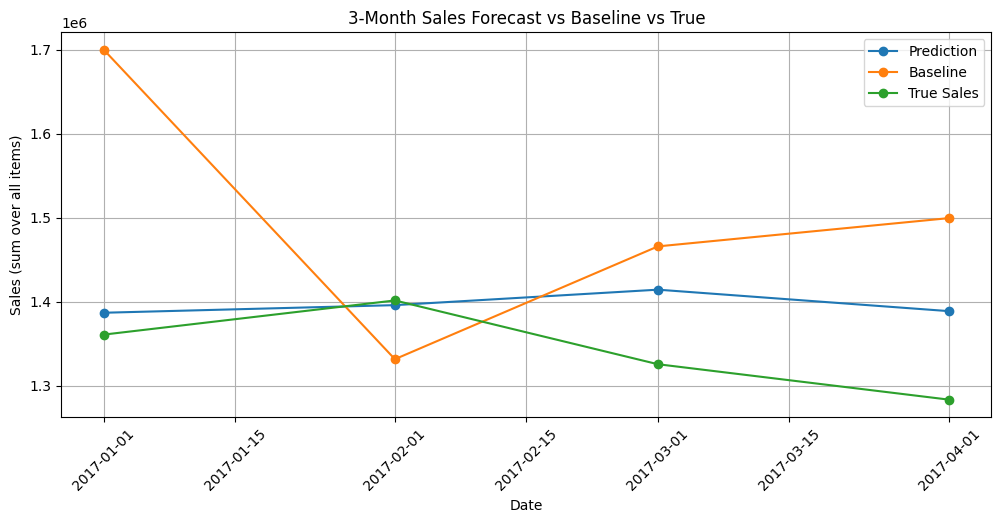

In [25]:
def plot_aggregated_forecast(df_test_iter, date_col='year_month'):
    plt.figure(figsize=(12, 5))
    
    # Filter dates before May 2017
    if pd.api.types.is_period_dtype(df_test_iter[date_col]):
        df_test_iter = df_test_iter[df_test_iter[date_col] < pd.Period('2017-05', freq='M')]
    else:
        df_test_iter = df_test_iter[df_test_iter[date_col] < pd.Timestamp('2017-05-01')]
    
    # Aggregate (sum over all items) for each column
    df_sum = df_test_iter.groupby(date_col)[
        ['pred_sum_3_months', 'baseline_sum_3_months', 'true_sum_3_months']
    ].sum().reset_index()
    
    # Convert Period to Timestamp if needed
    x_vals = df_sum[date_col]
    if pd.api.types.is_period_dtype(x_vals):
        x_vals = x_vals.dt.to_timestamp()
    
    # Plot all three lines
    plt.plot(x_vals, df_sum['pred_sum_3_months'], marker='o', label='Prediction')
    plt.plot(x_vals, df_sum['baseline_sum_3_months'], marker='o', label='Baseline')
    plt.plot(x_vals, df_sum['true_sum_3_months'], marker='o', label='True Sales')
    
    plt.title('3-Month Sales Forecast vs Baseline vs True')
    plt.xlabel('Date')
    plt.ylabel('Sales (sum over all items)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.show()

plot_aggregated_forecast(df_test_iter, date_col='year_month')


## 8.2 Plot Daily Total Sales + Forecasts - BASELINE, XGB

In [ ]:
# Plot total sales: actuals (train/test), test predictions, and forecast

train_total = df_trainval.groupby('date')['unit_sales'].sum().reset_index()
test_total = df_test_final.groupby('date')[['unit_sales', 'pred_lgb']].sum().reset_index()
forecast_total = daily_forecast_xgb.groupby('date')['pred_lgb'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(train_total['date'], train_total['unit_sales'], label='Train Actual', color='blue')
plt.plot(test_total['date'], test_total['unit_sales'], label='Test Actual', color='green')
plt.plot(test_total['date'], test_total['pred_xgb'], label='Test Prediction (XGB)', color='orange')
plt.plot(forecast_total['date'], forecast_total['pred_xgb'], label='7-Day Forecast (XGB)', color='red', marker='o')

plt.title('Total Sales: Actuals, Predictions, and 7-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

## 8.3 Plot Daily Total Sales + Forecasts for an ITEM/STORE combination - BASELINE, XGB

In [ ]:
# Plot actuals and predictions for train, test, and forecast for a single store/item
from datetime import datetime
store_id = 44
item_id = 1971328

# Get data for this store/item
df_train = df_trainval[(df_trainval['store_nbr'] == store_id) & (df_trainval['item_nbr'] == item_id)].copy()
df_test = df_test_final[(df_test_final['store_nbr'] == store_id) & (df_test_final['item_nbr'] == item_id)].copy()
df_forecast_xgb = daily_forecast_xgb[(daily_forecast_xgb['store_nbr'] == store_id) & (daily_forecast_xgb['item_nbr'] == item_id)].copy()
df_train = df_train.reset_index().copy()
df_test = df_test.reset_index().copy()
df_forecast_xgb = df_forecast_xgb.reset_index().copy()

plt.figure(figsize=(14, 6))


plt.plot(df_train['date'], df_train['unit_sales'], label='Train Actual', color='blue')
plt.plot(df_test['date'], df_test['unit_sales'], label='Test Actual', color='green')
plt.plot(df_test['date'], df_test['pred_xgb'], label='Test Prediction (XGB)', color='orange')
plt.plot(df_forecast_xgb['date'], df_forecast_xgb['pred_xgb'], label='7-Day Forecast (XGB)', color='red', marker='o')

plt.title(f'Store {store_id}, Item {item_id}: Actuals, Predictions, and Forecast')
plt.xlabel('Date')
plt.xlim(left=datetime(2017, 3, 1), right=datetime(2017,11,1) )
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

## 9. Save Forecast Outputs

Save the daily, weekly, and monthly forecast DataFrames to CSV files for downstream use.

In [ ]:
daily_forecast_xgb.to_csv('../data/daily_forecast_xgb.csv', index=False)
weekly_forecast_2weeks_xgb.to_csv('../data/weekly_forecast_xgb.csv', index=False)
monthly_forecast_2months_xgb.to_csv('../data/monthly_forecast_xgb.csv', index=False)



In [ ]:
# Analyze feature correlations and importance
print("Feature correlations with target (unit_sales):")
correlations = df_model[WEEKLY_FEATURES + [TARGET]].corr()[TARGET].sort_values(ascending=False)
print(correlations.to_string())

print("\nFeature correlations with baseline_ratio:")
baseline_corr = df_model[WEEKLY_FEATURES].corrwith(df_model['baseline_ratio']).sort_values(ascending=False)
print(baseline_corr.to_string())

# Check data distribution before/after transformation
if 'baseline_ratio' in df_model.columns and 'log_baseline_ratio' in df_model.columns:
    print("\nBaseline ratio stats:")
    print(df_model['baseline_ratio'].describe())
    print("\nlog_baseline_ratio stats:")
    print(df_model['log_baseline_ratio'].describe())

    # Check if we have any extreme values that might be affecting the model
    print("\nExtreme values check:")
    print(f"Values > 10x baseline: {(df_model['baseline_ratio'] > 10).sum():,} records")
    print(f"Values < 0.1x baseline: {(df_model['baseline_ratio'] < 0.1).sum():,} records")

# Print correlation matrix heatmap data
print("\nFeature correlation matrix:")
correlation_matrix = df_model[WEEKLY_FEATURES].corr().round(3)
print(correlation_matrix.to_string())